# PointNet on ModelNet40 — v1 → v2 → v3 Ablation

## Why this notebook exists

ModelNet10 (10 pre-aligned classes) saturated for us at 0.9174 with v1 (minimal PointNet, no T-Net). Four experiments — v1, v1+aug, v2, v2+aug — failed to improve on it because (a) the test set is pre-aligned so T-Net has no real work to do, (b) the desk↔table / dresser↔night_stand confusions dominate the small class set, and (c) ModelNet10 has no canonical benchmark to chase. ModelNet40 (40 diverse classes) is the dataset the original PointNet paper actually benchmarks against, and it's where T-Net's contribution is supposed to manifest.


## Environment, imports setup

In [1]:
import os
import time
import zipfile
import urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers '3d' projection)
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device selection: CUDA -> MPS -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Project paths — resolve defensively so the notebook works whether launched
# from project root or from notebooks/
_cwd = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd

DATA_ROOT     = os.path.join(PROJECT_ROOT, "data")
DATA_DIR_M40  = os.path.join(DATA_ROOT, "ModelNet40")      # extracted dataset
ZIP_PATH_M40  = os.path.join(DATA_ROOT, "ModelNet40.zip")  # raw download
CACHE_DIR_M40 = os.path.join(DATA_ROOT, "cache_modelnet40_1024pts")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")

# Make sure parent folders exist
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(CACHE_DIR_M40, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
print(f"Project root    : {PROJECT_ROOT}")
print(f"ModelNet40 dir  : {DATA_DIR_M40}")
print(f"  exists?       : {os.path.isdir(DATA_DIR_M40)}")
print(f"Cache dir       : {CACHE_DIR_M40}")
print(f"Checkpoints     : {CHECKPOINT_DIR}")

PyTorch version : 2.12.0
Device          : mps
Project root    : /Users/dosvatsky/3D Object Detection
ModelNet40 dir  : /Users/dosvatsky/3D Object Detection/data/ModelNet40
  exists?       : False
Cache dir       : /Users/dosvatsky/3D Object Detection/data/cache_modelnet40_1024pts
Checkpoints     : /Users/dosvatsky/3D Object Detection/checkpoints


#  Downloading and extracting ModelNet40

In [2]:
URLS_M40 = [
    "http://modelnet.cs.princeton.edu/ModelNet40.zip",
    "https://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet40.zip",
]


def download_with_progress(url, dest):
    """Download with a simple percentage progress bar that updates in place."""
    def hook(block_num, block_size, total_size):
        downloaded = block_num * block_size
        if total_size > 0:
            percent = min(100, downloaded * 100 / total_size)
            mb_done  = downloaded / 1024**2
            mb_total = total_size / 1024**2
            print(f"\r  {percent:5.1f}%  ({mb_done:7.1f} / {mb_total:7.1f} MB)", end="")
    urllib.request.urlretrieve(url, dest, reporthook=hook)
    print()  # newline after progress finishes


# ---- A. Download (skip if zip is already present and at least 1 GB) ----
if os.path.exists(ZIP_PATH_M40) and os.path.getsize(ZIP_PATH_M40) > 1e9:
    size_mb = os.path.getsize(ZIP_PATH_M40) / 1024**2
    print(f"Zip already exists at {ZIP_PATH_M40} ({size_mb:.1f} MB) -- skipping download")
else:
    print("Downloading ModelNet40.zip (about 1.7 GB)...")
    download_success = False
    for url in URLS_M40:
        try:
            print(f"  Trying: {url}")
            download_with_progress(url, ZIP_PATH_M40)
            download_success = True
            print(f"  OK: downloaded to {ZIP_PATH_M40}")
            break
        except Exception as e:
            print(f"  FAILED: {e}")
            if os.path.exists(ZIP_PATH_M40):
                os.remove(ZIP_PATH_M40)
    if not download_success:
        raise RuntimeError(
            "All Princeton URLs failed. Manually download ModelNet40.zip and place at:\n"
            f"  {ZIP_PATH_M40}\n"
            "Then re-run this cell."
        )


# ---- B. Extract (skip if a known class folder already exists) ----
if os.path.isdir(os.path.join(DATA_DIR_M40, "airplane")):
    print(f"\nModelNet40 already extracted at {DATA_DIR_M40} -- skipping extraction")
else:
    print(f"\nExtracting ModelNet40.zip to {DATA_ROOT}/ ...")
    with zipfile.ZipFile(ZIP_PATH_M40, "r") as zf:
        zf.extractall(DATA_ROOT)
    print(f"  OK: extracted to {DATA_DIR_M40}")


# ---- C. Verify class folders ----
class_folders = sorted([
    d for d in os.listdir(DATA_DIR_M40)
    if os.path.isdir(os.path.join(DATA_DIR_M40, d))
    and not d.startswith(("_", "."))
])
print(f"\nFound {len(class_folders)} class folders:")
for i, c in enumerate(class_folders):
    print(f"  {i:>2}  {c}")

assert len(class_folders) == 40, f"Expected 40 classes, found {len(class_folders)}"
print("\nModelNet40 ready.")

  Trying: http://modelnet.cs.princeton.edu/ModelNet40.zip
  100.0%  ( 1944.7 /  1944.7 MB)
  OK: downloaded to /Users/dosvatsky/3D Object Detection/data/ModelNet40.zip

Extracting ModelNet40.zip to /Users/dosvatsky/3D Object Detection/data/ ...
  OK: extracted to /Users/dosvatsky/3D Object Detection/data/ModelNet40

Found 40 class folders:
   0  airplane
   1  bathtub
   2  bed
   3  bench
   4  bookshelf
   5  bottle
   6  bowl
   7  car
   8  chair
   9  cone
  10  cup
  11  curtain
  12  desk
  13  door
  14  dresser
  15  flower_pot
  16  glass_box
  17  guitar
  18  keyboard
  19  lamp
  20  laptop
  21  mantel
  22  monitor
  23  night_stand
  24  person
  25  piano
  26  plant
  27  radio
  28  range_hood
  29  sink
  30  sofa
  31  stairs
  32  stool
  33  table
  34  tent
  35  toilet
  36  tv_stand
  37  vase
  38  wardrobe
  39  xbox

ModelNet40 ready.


## Inspecting dataset structure and class balance

idx  class            train    test   total
--------------------------------------------------
  0  airplane           626     100     726
  1  bathtub            106      50     156
  2  bed                515     100     615
  3  bench              173      20     193
  4  bookshelf          572     100     672
  5  bottle             335     100     435
  6  bowl                64      20      84
  7  car                197     100     297
  8  chair              889     100     989
  9  cone               167      20     187
 10  cup                 79      20      99
 11  curtain            138      20     158
 12  desk               200      86     286
 13  door               109      20     129
 14  dresser            200      86     286
 15  flower_pot         149      20     169
 16  glass_box          171     100     271
 17  guitar             155     100     255
 18  keyboard           145      20     165
 19  lamp               124      20     144
 20  laptop             1

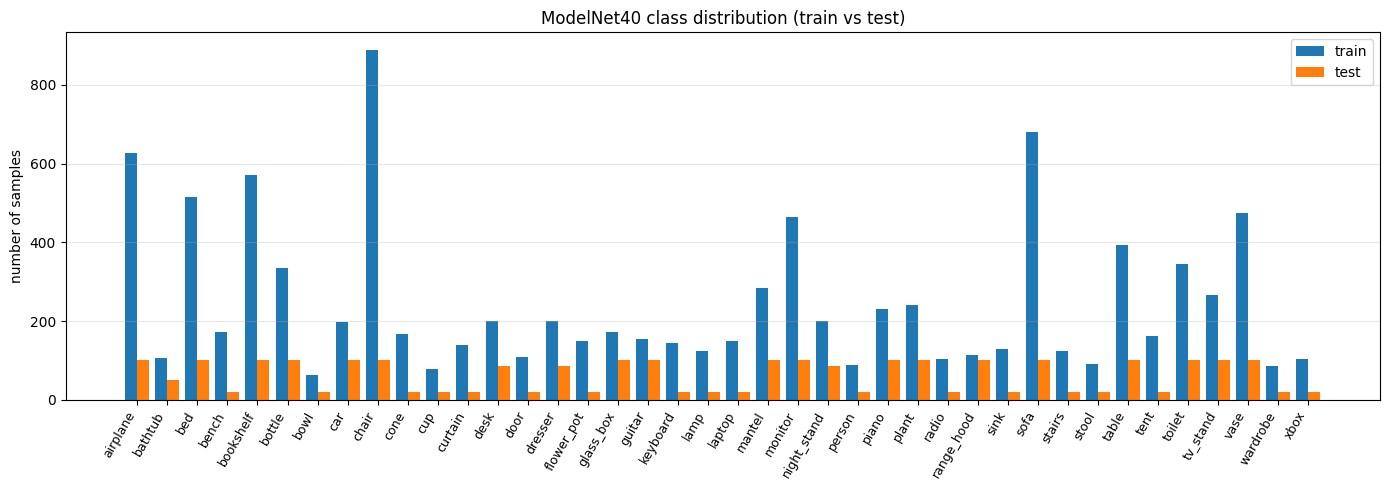

In [3]:
CLASSES_M40 = sorted([
    d for d in os.listdir(DATA_DIR_M40)
    if os.path.isdir(os.path.join(DATA_DIR_M40, d))
    and not d.startswith(("_", "."))
])
CLASS_TO_IDX_M40 = {c: i for i, c in enumerate(CLASSES_M40)}
IDX_TO_CLASS_M40 = {i: c for c, i in CLASS_TO_IDX_M40.items()}

# ---- Count files per class per split ----
print(f"{'idx':>3}  {'class':<14}  {'train':>6}  {'test':>6}  {'total':>6}")
print("-" * 50)

train_counts, test_counts = [], []
for i, c in enumerate(CLASSES_M40):
    train_dir = os.path.join(DATA_DIR_M40, c, "train")
    test_dir  = os.path.join(DATA_DIR_M40, c, "test")
    n_train = len([f for f in os.listdir(train_dir) if f.endswith(".off")]) if os.path.isdir(train_dir) else 0
    n_test  = len([f for f in os.listdir(test_dir)  if f.endswith(".off")]) if os.path.isdir(test_dir)  else 0
    train_counts.append(n_train)
    test_counts.append(n_test)
    print(f"{i:>3}  {c:<14}  {n_train:>6}  {n_test:>6}  {n_train + n_test:>6}")

print("-" * 50)
total_train = sum(train_counts)
total_test  = sum(test_counts)
print(f"{'':>3}  {'TOTAL':<14}  {total_train:>6}  {total_test:>6}  {total_train + total_test:>6}")

# ---- Balance summary ----
min_idx = int(np.argmin(train_counts))
max_idx = int(np.argmax(train_counts))
sorted_counts = sorted(train_counts)
print(f"\nClass balance (train set):")
print(f"  Smallest class : '{CLASSES_M40[min_idx]}' ({min(train_counts)} samples)")
print(f"  Largest class  : '{CLASSES_M40[max_idx]}' ({max(train_counts)} samples)")
print(f"  Mean / median  : {np.mean(train_counts):.0f} / {sorted_counts[20]:.0f}")
print(f"  Imbalance ratio (max / min) : {max(train_counts) / min(train_counts):.1f}x")

# ---- Bar chart of class sizes ----
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(40)
width = 0.4
ax.bar(x - width/2, train_counts, width, label="train")
ax.bar(x + width/2, test_counts,  width, label="test")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES_M40, rotation=60, ha="right", fontsize=9)
ax.set_ylabel("number of samples")
ax.set_title("ModelNet40 class distribution (train vs test)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

##  Define the ModelNet40 Dataset class and doing a Sanity Check 

In [4]:
import io
import glob
import trimesh


def _safe_load_off(fp):
    """Load an OFF file, fixing the malformed 'OFF<digits>' header bug
    that some ModelNet40 files have (header and counts on the same line).
    """
    with open(fp, "r") as f:
        content = f.read()
    if content.startswith("OFF") and len(content) > 3 and content[3] != "\n":
        # Bad: "OFF684 1180 0\n..."  -> insert newline after OFF
        content = "OFF\n" + content[3:]
        return trimesh.load(io.StringIO(content), file_type="off", force="mesh")
    return trimesh.load(fp, force="mesh")


class ModelNet40Dataset(Dataset):
    """PyTorch Dataset for ModelNet40.

    Walks data/ModelNet40/<class>/<split>/*.off, loads each mesh with trimesh,
    samples `num_points` from the mesh surface, normalizes to a unit sphere
    centered at the origin, and returns (points_tensor, label_int).
    """
    def __init__(self, root, split="train", num_points=1024):
        assert split in {"train", "test"}, "split must be 'train' or 'test'"
        self.root = root
        self.split = split
        self.num_points = num_points

        # Collect (filepath, label) pairs once, sorted for reproducibility
        self.samples = []
        for class_name in CLASSES_M40:
            class_dir = os.path.join(root, class_name, split)
            if not os.path.isdir(class_dir):
                continue
            for fp in sorted(glob.glob(os.path.join(class_dir, "*.off"))):
                self.samples.append((fp, CLASS_TO_IDX_M40[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        mesh = _safe_load_off(fp)
        points, _ = trimesh.sample.sample_surface(mesh, self.num_points)
        points = np.asarray(points, dtype=np.float32)
        # Normalize: center to origin, scale so max radius == 1 (unit sphere)
        points = points - points.mean(axis=0, keepdims=True)
        scale = np.max(np.linalg.norm(points, axis=1))
        points = points / scale
        return torch.from_numpy(points), label


# Instantiate train + test
train_ds_m40 = ModelNet40Dataset(DATA_DIR_M40, split="train", num_points=1024)
test_ds_m40  = ModelNet40Dataset(DATA_DIR_M40, split="test",  num_points=1024)

print(f"Train samples: {len(train_ds_m40)}  (expected 9843)")
print(f"Test samples : {len(test_ds_m40)}   (expected 2468)")

# Sanity check on one training sample
points, label = train_ds_m40[0]
print(f"\n--- Sanity check on train_ds_m40[0] ---")
print(f"  points.shape       : {tuple(points.shape)}     (expected (1024, 3))")
print(f"  points.dtype       : {points.dtype}            (expected torch.float32)")
print(f"  label              : {label}  ({IDX_TO_CLASS_M40[label]})")
print(f"  centered? mean     : {points.mean(0).numpy().round(4)}  (expected ~[0, 0, 0])")
print(f"  unit-sphere? max r : {points.norm(dim=1).max().item():.4f}  (expected 1.0000)")

Train samples: 9843  (expected 9843)
Test samples : 2468   (expected 2468)

--- Sanity check on train_ds_m40[0] ---
  points.shape       : (1024, 3)     (expected (1024, 3))
  points.dtype       : torch.float32            (expected torch.float32)
  label              : 0  (airplane)
  centered? mean     : [ 0.  0. -0.]  (expected ~[0, 0, 0])
  unit-sphere? max r : 1.0000  (expected 1.0000)


## Pre-caching  point clouds 

In [5]:
from tqdm.auto import tqdm


def precache_split_m40(dataset, split_name):
    """Sample every mesh once, save (points, labels) as .npz.
    Skips files that fail to load and logs them.
    """
    cache_path = os.path.join(CACHE_DIR_M40, f"{split_name}.npz")
    if os.path.exists(cache_path):
        size_mb = os.path.getsize(cache_path) / 1024**2
        print(f"Cache for '{split_name}' already exists at {cache_path} ({size_mb:.1f} MB) -- skipping")
        return cache_path

    all_points = []
    all_labels = []
    failed = []

    for i in tqdm(range(len(dataset)), desc=f"Caching {split_name}"):
        try:
            pts, lbl = dataset[i]
            all_points.append(pts.numpy())
            all_labels.append(lbl)
        except Exception as e:
            failed.append((i, dataset.samples[i][0], str(e)))

    points_arr = np.stack(all_points)
    labels_arr = np.array(all_labels, dtype=np.int64)

    if failed:
        print(f"\nWARNING: {len(failed)} / {len(dataset)} files failed to load:")
        for idx, fp, err in failed[:5]:
            print(f"  [{idx}] {os.path.basename(fp)}: {err}")
        if len(failed) > 5:
            print(f"  ... and {len(failed) - 5} more")
        print(f"  These samples are skipped (not in the cache).")

    np.savez(cache_path, points=points_arr, labels=labels_arr)
    size_mb = os.path.getsize(cache_path) / 1024**2
    print(f"\nSaved '{split_name}' cache: shape {points_arr.shape}, {size_mb:.1f} MB")
    return cache_path


print("Pre-caching ModelNet40 (one-time, ~15 min)...\n")
train_cache_path_m40 = precache_split_m40(train_ds_m40, "train")
test_cache_path_m40  = precache_split_m40(test_ds_m40,  "test")
print("\nCaching complete.")

Pre-caching ModelNet40 (one-time, ~15 min)...



Caching train:   0%|          | 0/9843 [00:00<?, ?it/s]

/Users/dosvatsky/3D Object Detection/venv/lib/python3.13/site-packages/trimesh/grouping.py:99: RuntimeWarning: invalid value encountered in cast
  stacked = np.column_stack(stacked).round().astype(np.int64)



Saved 'train' cache: shape (9843, 1024, 3), 115.4 MB


Caching test:   0%|          | 0/2468 [00:00<?, ?it/s]


Saved 'test' cache: shape (2468, 1024, 3), 28.9 MB

Caching complete.


## DataLoading and sample visualization

In [6]:
class CachedModelNet40(Dataset):
    """Reads pre-sampled ModelNet40 point clouds from the .npz cache."""
    def __init__(self, cache_path):
        data = np.load(cache_path)
        self.points = data["points"]   # (n, 1024, 3) float32
        self.labels = data["labels"]   # (n,) int64

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.from_numpy(self.points[idx]), int(self.labels[idx])


BATCH_SIZE = 32

train_cached_m40 = CachedModelNet40(train_cache_path_m40)
test_cached_m40  = CachedModelNet40(test_cache_path_m40)

# num_workers=0 on macOS (multiprocessing with torch DataLoaders can be flaky on MPS)
train_loader_m40 = DataLoader(train_cached_m40, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=0, drop_last=True)
test_loader_m40  = DataLoader(test_cached_m40,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0)

print(f"Train (cached): {len(train_cached_m40)} samples, {len(train_loader_m40)} batches")
print(f"Test  (cached): {len(test_cached_m40)} samples, {len(test_loader_m40)} batches")

# Timing sanity: pull one batch
start = time.time()
pts, lbls = next(iter(train_loader_m40))
elapsed = time.time() - start

print(f"\n--- One training batch ---")
print(f"  points.shape : {tuple(pts.shape)}    (expected ({BATCH_SIZE}, 1024, 3))")
print(f"  points.dtype : {pts.dtype}")
print(f"  labels.shape : {tuple(lbls.shape)}            (expected ({BATCH_SIZE},))")
print(f"  unique labels in batch: {sorted(set(lbls.tolist()))} ({len(set(lbls.tolist()))} of 40)")
print(f"  load time    : {elapsed*1000:.1f} ms  (vs ~3000 ms uncached)")

Train (cached): 9843 samples, 307 batches
Test  (cached): 2468 samples, 78 batches

--- One training batch ---
  points.shape : (32, 1024, 3)    (expected (32, 1024, 3))
  points.dtype : torch.float32
  labels.shape : (32,)            (expected (32,))
  unique labels in batch: [0, 1, 4, 5, 7, 8, 10, 13, 21, 22, 23, 25, 26, 30, 35, 36] (16 of 40)
  load time    : 41.5 ms  (vs ~3000 ms uncached)


## Visualizing some random samples from random different classes


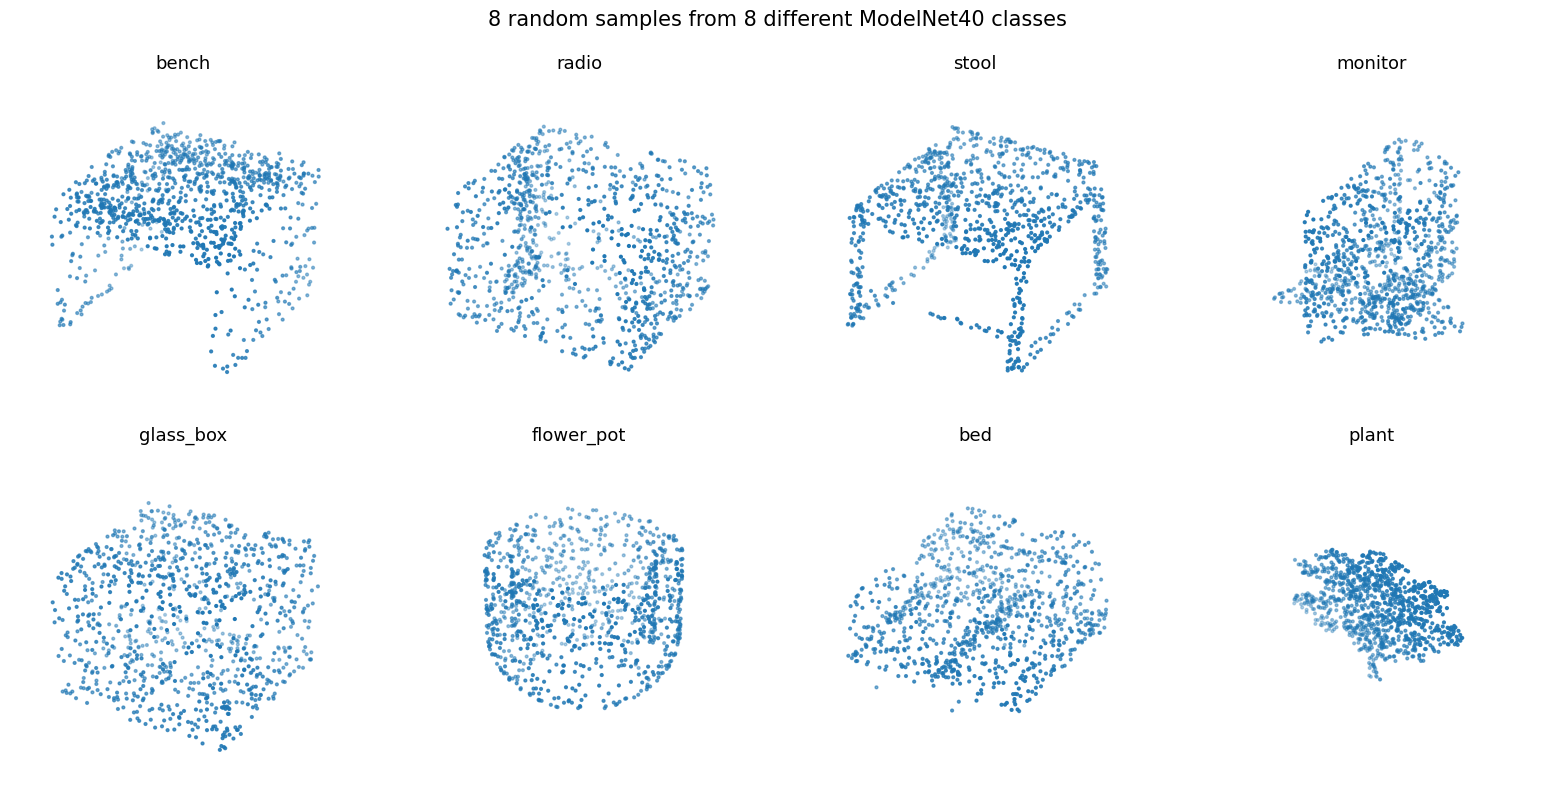

In [7]:
# Pick 8 random distinct classes, then pick one random sample from each
rng = np.random.default_rng(42)
chosen_classes = rng.choice(40, size=8, replace=False)

sample_indices = []
sample_labels = []
for cls in chosen_classes:
    cls_indices = np.where(train_cached_m40.labels == cls)[0]
    pick = rng.choice(cls_indices)
    sample_indices.append(int(pick))
    sample_labels.append(int(cls))

fig = plt.figure(figsize=(16, 8))
for plot_i, (idx, lbl) in enumerate(zip(sample_indices, sample_labels)):
    pts = train_cached_m40.points[idx]
    ax = fig.add_subplot(2, 4, plot_i + 1, projection="3d")
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=4)
    ax.set_title(f"{IDX_TO_CLASS_M40[lbl]}", fontsize=13)
    ax.set_axis_off()
plt.suptitle("8 random samples from 8 different ModelNet40 classes", fontsize=15, y=1.0)
plt.tight_layout()
plt.show()